# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura()

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)

In [4]:
del df

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
df_block['stimulus'].value_counts()

stimulus
1     132
0     132
3     132
4     132
6     132
9     132
10    132
11    132
Name: count, dtype: int64

# Filtro

In [6]:
df_block_filtered = dp.filtrar(df_block)

Procesando: 100%|██████████| 3/3 [00:25<00:00,  8.56s/it]


In [7]:
del df_block

# Extracción de características

In [9]:
df_block_features = dp.gen_carac(df_block_filtered)
del df_block_filtered

Extrayendo Características: 100%|██████████| 1056/1056 [00:32<00:00, 32.05it/s]


In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,zc_1,rms_2,iemg_2,mav_2,wl_2,log_detec_2,ssi_2,fft_2,psd_2,mf_2,mdf_2,zc_2,rms_3,iemg_3,mav_3,wl_3,log_detec_3,ssi_3,fft_3,psd_3,mf_3,mdf_3,zc_3,rms_4,iemg_4,mav_4,wl_4,log_detec_4,ssi_4,fft_4,...,ssi_11,fft_11,psd_11,mf_11,mdf_11,zc_11,rms_12,iemg_12,mav_12,wl_12,log_detec_12,ssi_12,fft_12,psd_12,mf_12,mdf_12,zc_12,rms_13,iemg_13,mav_13,wl_13,log_detec_13,ssi_13,fft_13,psd_13,mf_13,mdf_13,zc_13,rms_14,iemg_14,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.00000,1056.000000,1056.000000,1.056000e+03,1056.000000,1056.000000,1.056000e+03,1.056000e+03,1056.000000,...,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1056.000000,1.056000e+03,1056.000000,1056.000000,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1056.000000,1056.000000,1056.000000,1056.000000
mean,0.000034,4.693922e-08,0.000020,0.112569,0.000009,6.995103e-09,0.001946,1.507262e-12,217.449276,81.914773,1506.103220,0.000018,1.543495e-07,0.000012,0.048713,0.000006,1.629575e-09,0.000895,3.601251e-13,177.293264,51.036932,1319.256629,0.000010,4.867917e-08,0.000007,0.025024,0.000004,5.774116e-10,0.000464,1.245818e-13,155.163308,36.31250,1179.089015,0.000006,6.310470e-09,0.000004,0.016058,2.671859e-06,1.794379e-10,0.000272,...,1.465152e-09,0.000548,3.362933e-13,157.402779,38.161932,1197.825758,0.000007,-1.236832e-08,0.000005,0.019169,0.000003,4.801712e-10,0.000330,1.077236e-13,172.552041,40.469697,1357.718750,0.000006,-4.377647e-08,0.000005,0.018433,0.000003,3.757937e-10,0.000310,8.421059e-14,181.085535,42.643939,1426.175189,0.000008,6.716367e-09,0.000005,0.020962,2.906786e-06,1.213184e-09,0.000372,2.970708e-13,180.623041,46.659091,1429.200758,5.500000
std,0.000017,2.351786e-07,0.000009,0.061759,0.000003,8.120465e-09,0.001048,1.696341e-12,22.756036,16.792583,225.424868,0.000006,1.778882e-07,0.000004,0.019759,0.000002,1.053293e-09,0.000299,2.266142e-13,15.406746,9.093801,202.779645,0.000004,1.210624e-07,0.000003,0.010320,0.000002,5.680967e-10,0.000194,1.182600e-13,9.681391,6.46367,153.062957,0.000002,4.458565e-08,0.000002,0.005815,9.638372e-07,1.612336e-10,0.000097,...,6.641382e-09,0.000317,1.540927e-12,16.485463,11.271711,195.578461,0.000007,1.153073e-07,0.000004,0.007633,0.000002,1.719937e-09,0.000208,3.895959e-13,16.237626,10.390801,209.901795,0.000006,2.648303e-07,0.000003,0.007554,0.000002,1.675680e-09,0.000197,3.799916e-13,14.475833,9.795643,205.033190,0.000014,1.720946e-07,0.000004,0.009324,1.363055e-06,2.660676e-08,0.000426,6.857602e-12,15.066878,9.415590,182.233576,3.906975
min,0.000008,-1.174226e-06,0.000005,0.016605,0.000002,2.312092e-10,0.000373,6.547629e-14,176.314297,48.000000,879.000000,0.000006,-3.228778e-07,0.000004,0.012192,0.000002,1.435585e-10,0.000262,4.008403e-14,138.247647,27.000000,735.000000,0.000004,-3.705954e-07,0.000003,0.008148,0.000002,5.833409e-11,0.000163,1.314381e-14,122.903415,16.00000,621.000000,0.000003,-1.622048e-07,0.000002,0.006697,1.332602e-06,3.216969e-11,0.000133,...,6.494952e-11,0.000184,1.500673e-14,72.153266,10.000000,288.000000,0.000003,-1.571897e-06,0.000002,0.006892,0.000001,3.001864e-11,0.000128,6.845660e-15,86.812847,10.000000,466.000000,0.000002,-5.118172e-06,0.000002,0.006228,0.000001,1.880614e-11,0.000105,5.031410e-15,99.315737,11.000000,669.000000,0.0000

# Normalización

In [11]:
df_block_normalized = dp.normalizar(df_block_features)
# del df_block_features

In [12]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,zc_1,rms_2,iemg_2,mav_2,wl_2,log_detec_2,ssi_2,fft_2,psd_2,mf_2,mdf_2,zc_2,rms_3,iemg_3,mav_3,wl_3,log_detec_3,ssi_3,fft_3,psd_3,mf_3,mdf_3,zc_3,rms_4,iemg_4,mav_4,wl_4,log_detec_4,ssi_4,fft_4,...,ssi_11,fft_11,psd_11,mf_11,mdf_11,zc_11,rms_12,iemg_12,mav_12,wl_12,log_detec_12,ssi_12,fft_12,psd_12,mf_12,mdf_12,zc_12,rms_13,iemg_13,mav_13,wl_13,log_detec_13,ssi_13,fft_13,psd_13,mf_13,mdf_13,zc_13,rms_14,iemg_14,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,...,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1.056000e+03,1056.000000
mean,-1.884015e-16,-3.364312e-17,-4.037175e-17,-1.076580e-16,1.749442e-16,8.074349e-17,0.000000,5.382900e-17,7.536059e-16,-3.498885e-16,-2.287732e-16,1.345725e-16,2.691450e-17,-5.921189e-16,1.884015e-16,2.691450e-16,-2.691450e-17,1.345725e-17,-9.420074e-17,8.343494e-16,-1.749442e-16,1.614870e-16,-4.037175e-16,9.420074e-17,1.614870e-16,-2.153160e-16,4.844610e-16,0.000000,-2.960595e-16,-1.614870e-16,-9.689219e-16,0.000000,-5.853903e-16,-8.074349e-17,6.728624e-18,2.422305e-16,-8.074349e-17,3.498885e-16,-1.614870e-16,-3.498885e-16,...,-2.691450e-17,-8.074349e-17,0.000000,3.229740e-16,-2.153160e-16,3.498885e-16,-2.691450e-17,-6.728624e-18,2.153160e-16,-5.382900e-17,5.382900e-17,1.345725e-17,-1.345725e-16,-4.037175e-17,-3.768030e-16,5.382900e-17,0.000000,1.076580e-16,-2.355019e-17,2.691450e-16,-2.153160e-16,1.076580e-16,0.000000,1.345725e-16,-1.345725e-17,9.958364e-16,2.691450e-16,-4.777323e-16,-5.382900e-17,0.000000,-1.345725e-16,-8.074349e-17,-5.382900e-17,1.009294e-17,1.076580e-16,3.364312e-18,5.113755e-16,2.153160e-16,3.768030e-16,5.500000
std,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,...,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,1.000474e+00,3.906975
min,-1.559187e+00,-5.194963e+00,-1.795006e+00,-1.554580e+00,-2.002664e+00,-8.333388e-01,-1.501971,-8.503414e-01,-1.808508e+00,-2.020585e+00,-2.783191e+00,-2.049182e+00,-2.684009e+00,-2.006716e+00,-1.849214e+00,-2.040761e+00,-1.411497e+00,-2.113571e+00,-1.412942e+00,-2.535520e+00,-2.644474e+00,-2.882604e+00,-1.491962e+00,-3.464933e+

# Creación de dataframes de entrenamiento y testeo

In [13]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

del df_block_normalized

In [14]:
print(X_train.shape,y_train.shape)

(739, 154) (739,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [15]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Hidden Markov model (HMM)
from hmmlearn import hmm
from sklearn.preprocessing import LabelEncoder

In [31]:
# Visualization libraries

import seaborn as sns

Random forest

In [16]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 1218 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 2418 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    3.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    0.0s
[Parallel(n_job

Rotation forest

In [47]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)

Artificial Neural Networks (ANN)

In [18]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8
Epoch 1/50


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2238 - loss: 2.2765 - val_accuracy: 0.5676 - val_loss: 1.3262
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5657 - loss: 1.1982 - val_accuracy: 0.6622 - val_loss: 0.9723
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7300 - loss: 0.8230 - val_accuracy: 0.7365 - val_loss: 0.7420
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7660 - loss: 0.5937 - val_accuracy: 0.7973 - val_loss: 0.5987
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8394 - loss: 0.4822 - val_accuracy: 0.8311 - val_loss: 0.5297
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8632 - loss: 0.4253 - val_accuracy: 0.8649 - val_loss: 0.4414
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8964 - loss: 0.3189 - val_accuracy: 0.8784 - val_loss: 0.3912
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8727 - loss: 0.3584 - val_accuracy: 0.8851 - val_loss: 0.3494
Ep

# Resultados

Random forest

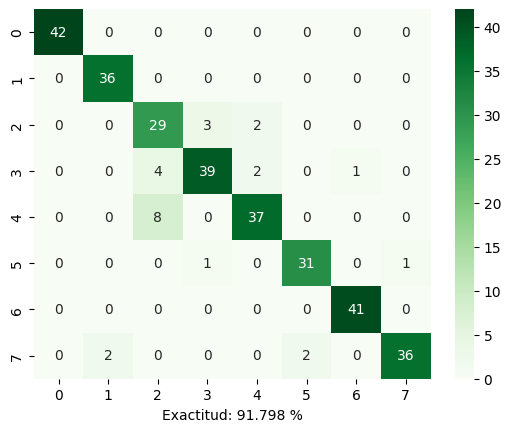

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       0.95      1.00      0.97        36
           3       0.71      0.85      0.77        34
           4       0.91      0.85      0.88        46
           6       0.90      0.82      0.86        45
           9       0.94      0.94      0.94        33
          10       0.98      1.00      0.99        41
          11       0.97      0.90      0.94        40

    accuracy                           0.92       317
   macro avg       0.92      0.92      0.92       317
weighted avg       0.92      0.92      0.92       317



In [44]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Rotation forest

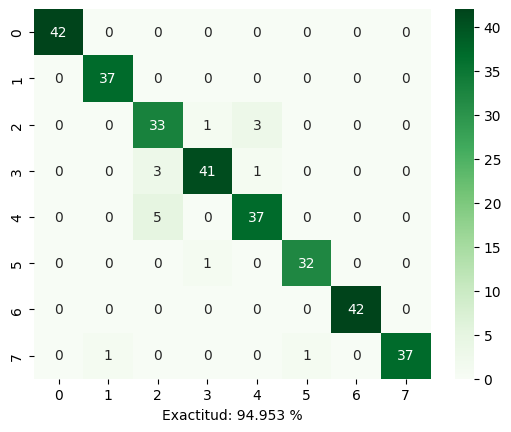

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       0.97      1.00      0.99        37
           3       0.80      0.89      0.85        37
           4       0.95      0.91      0.93        45
           6       0.90      0.88      0.89        42
           9       0.97      0.97      0.97        33
          10       1.00      1.00      1.00        42
          11       1.00      0.95      0.97        39

    accuracy                           0.95       317
   macro avg       0.95      0.95      0.95       317
weighted avg       0.95      0.95      0.95       317



In [48]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Artificial Neural Networks (ANN)

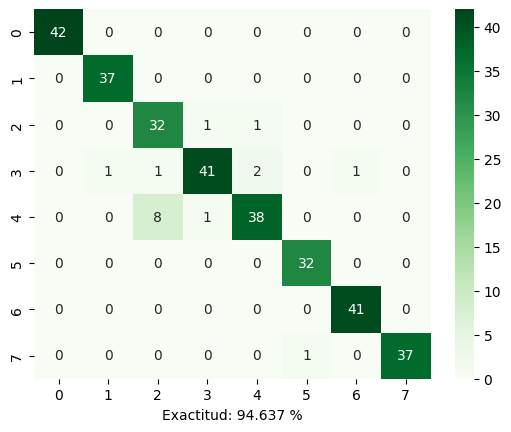

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       0.97      1.00      0.99        37
           3       0.78      0.94      0.85        34
           4       0.95      0.89      0.92        46
           6       0.93      0.81      0.86        47
           9       0.97      1.00      0.98        32
          10       0.98      1.00      0.99        41
          11       1.00      0.97      0.99        38

    accuracy                           0.95       317
   macro avg       0.95      0.95      0.95       317
weighted avg       0.95      0.95      0.95       317



In [46]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

# Con PCA

In [49]:
pca = PCA(0.95)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [52]:
print(X.shape)
print(X_pca.shape)

(1056, 154)
(1056, 33)


Random forest

In [54]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1218 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 2418 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    2.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    0.0s
[Parallel(n_job

Rotation forest

In [55]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)

Artificial Neural Networks (ANN)

In [56]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8
Epoch 1/50


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2013 - loss: 2.1588 - val_accuracy: 0.5068 - val_loss: 1.4277
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5027 - loss: 1.4277 - val_accuracy: 0.6351 - val_loss: 1.1227
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6983 - loss: 0.9382 - val_accuracy: 0.6689 - val_loss: 0.8974
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7316 - loss: 0.7696 - val_accuracy: 0.7568 - val_loss: 0.7501
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7679 - loss: 0.6648 - val_accuracy: 0.8041 - val_loss: 0.6270
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8119 - loss: 0.5320 - val_accuracy: 0.7838 - val_loss: 0.5750
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8422 - loss: 0.4598 - val_accuracy: 0.8108 - val_loss: 0.5337
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8985 - loss: 0.3722 - val_accuracy: 0.8446 - val_loss: 0.4574
Epo

# Resultados

Random forest

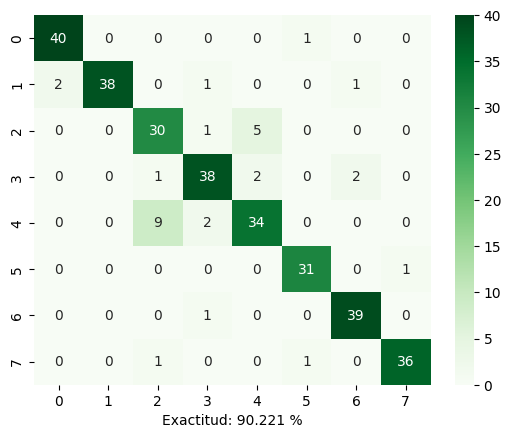

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        41
           1       1.00      0.90      0.95        42
           3       0.73      0.83      0.78        36
           4       0.88      0.88      0.88        43
           6       0.83      0.76      0.79        45
           9       0.94      0.97      0.95        32
          10       0.93      0.97      0.95        40
          11       0.97      0.95      0.96        38

    accuracy                           0.90       317
   macro avg       0.90      0.91      0.90       317
weighted avg       0.90      0.90      0.90       317



In [57]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

Rotation forest

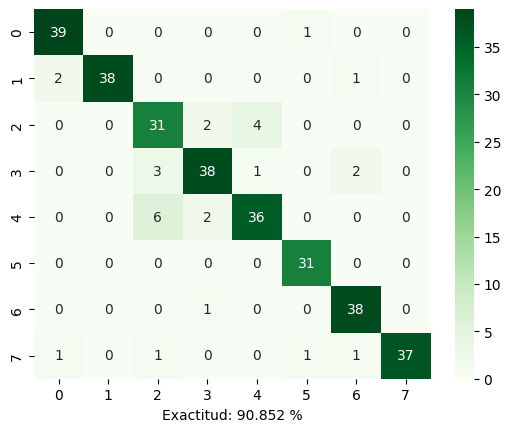

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        40
           1       1.00      0.93      0.96        41
           3       0.76      0.84      0.79        37
           4       0.88      0.86      0.87        44
           6       0.88      0.82      0.85        44
           9       0.94      1.00      0.97        31
          10       0.90      0.97      0.94        39
          11       1.00      0.90      0.95        41

    accuracy                           0.91       317
   macro avg       0.91      0.91      0.91       317
weighted avg       0.91      0.91      0.91       317



In [58]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

Artificial Neural Networks (ANN)

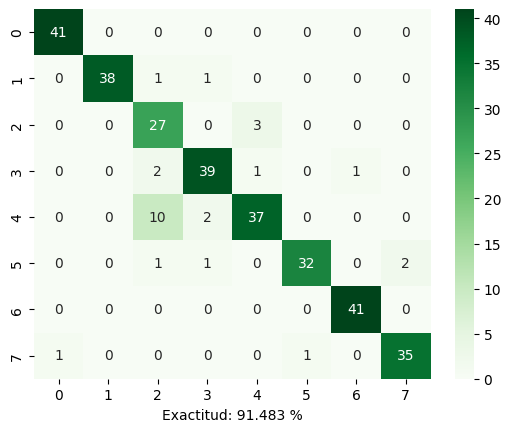

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        41
           1       1.00      0.95      0.97        40
           3       0.66      0.90      0.76        30
           4       0.91      0.91      0.91        43
           6       0.90      0.76      0.82        49
           9       0.97      0.89      0.93        36
          10       0.98      1.00      0.99        41
          11       0.95      0.95      0.95        37

    accuracy                           0.91       317
   macro avg       0.92      0.92      0.91       317
weighted avg       0.92      0.91      0.92       317



In [59]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

Rpoerte de PCA

In [60]:
pca.explained_variance_ratio_

array([0.24324624, 0.13673378, 0.10094781, 0.06381562, 0.05196576,
       0.04606727, 0.03903661, 0.03206455, 0.02951811, 0.02477419,
       0.01921272, 0.01664871, 0.0144219 , 0.01291247, 0.01225559,
       0.00946591, 0.00924199, 0.00841303, 0.00812131, 0.00723367,
       0.006901  , 0.00635749, 0.00619963, 0.00579064, 0.00559606,
       0.00538746, 0.00511559, 0.00487968, 0.00442027, 0.00415312,
       0.0039902 , 0.00358715, 0.00346846])